In [1]:
from google.colab import files
uploaded = files.upload()
# Upload all 6 CSV files

Saving 01_awareness_data.csv to 01_awareness_data.csv
Saving 02_consideration_data.csv to 02_consideration_data.csv
Saving 03_intent_data.csv to 03_intent_data.csv
Saving 04_conversion_data.csv to 04_conversion_data.csv
Saving 05_retention_data.csv to 05_retention_data.csv
Saving 06_full_funnel_summary.csv to 06_full_funnel_summary.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

COLORS = {
    'awareness':     '#1A5276',
    'consideration': '#2E86C1',
    'intent':        '#85C1E9',
    'conversion':    '#27AE60',
    'retention':     '#E74C3C',
    'highlight':     '#E67E22'
}

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Load data
conversion = pd.read_csv('04_conversion_data.csv', parse_dates=['date'])
retention  = pd.read_csv('05_retention_data.csv',  parse_dates=['date'])
funnel     = pd.read_csv('06_full_funnel_summary.csv', parse_dates=['date'])

print("✅ Data loaded!")
print(f"Avg CAC:          ${conversion['cac'].mean():.0f}")
print(f"Avg LTV:          ${retention['ltv'].mean():,.0f}")
print(f"Avg LTV:CAC:      {retention['ltv_cac_ratio'].mean():.1f}x")
print(f"Avg Churn Rate:   {retention['churn_rate_pct'].mean():.2f}%")

✅ Data loaded!
Avg CAC:          $19
Avg LTV:          $1,182
Avg LTV:CAC:      89.4x
Avg Churn Rate:   3.98%


#  LTV:CAC Ratio Analysis:

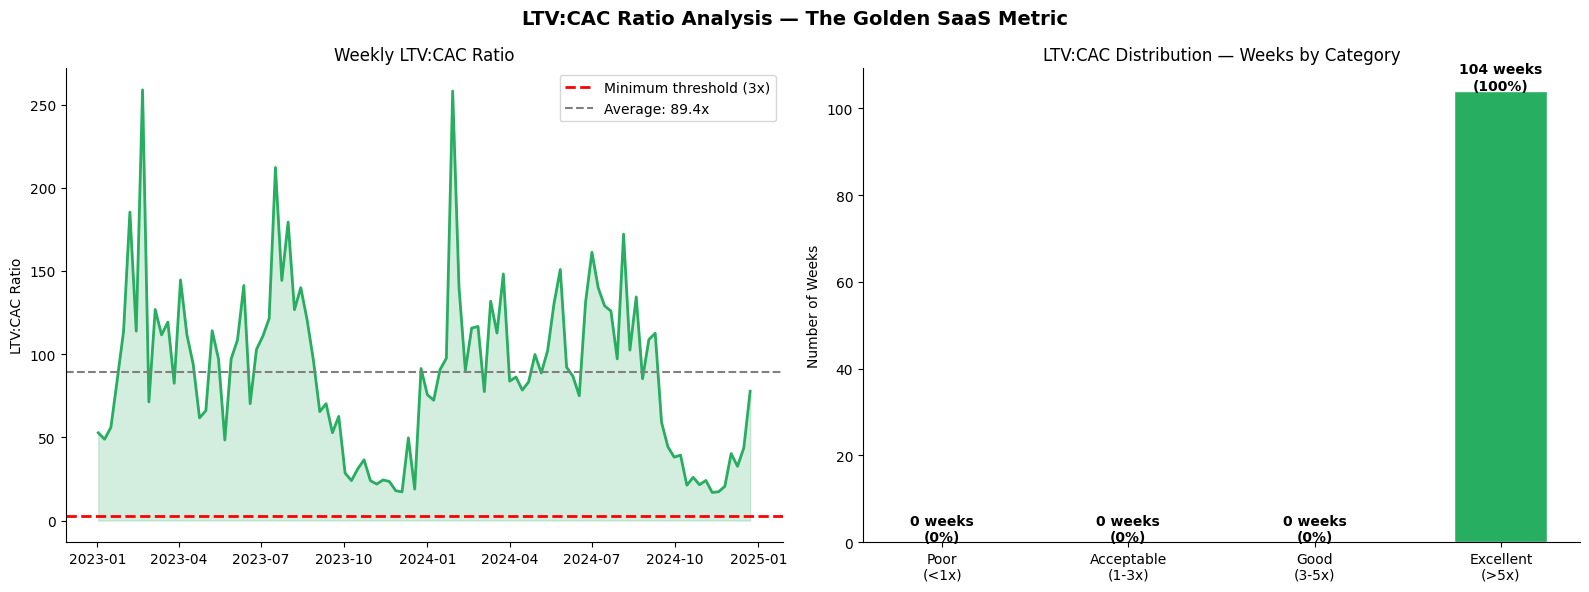

✅ LTV:CAC Analysis saved!
Weeks above 3x threshold: 104/104 (100%)


In [3]:
# The golden SaaS rule: LTV:CAC should be > 3x
ltv_cac_avg = retention['ltv_cac_ratio'].mean()
weeks_above_3 = (retention['ltv_cac_ratio'] > 3).sum()
weeks_total   = len(retention)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LTV:CAC Ratio Analysis — The Golden SaaS Metric',
             fontsize=14, fontweight='bold')

# LTV:CAC over time
axes[0].plot(retention['date'], retention['ltv_cac_ratio'],
             color=COLORS['conversion'], linewidth=2)
axes[0].fill_between(retention['date'], retention['ltv_cac_ratio'],
                     alpha=0.2, color=COLORS['conversion'])
axes[0].axhline(3, color='red', linestyle='--',
                linewidth=2, label='Minimum threshold (3x)')
axes[0].axhline(ltv_cac_avg, color='gray', linestyle='--',
                linewidth=1.5,
                label=f'Average: {ltv_cac_avg:.1f}x')
axes[0].set_title('Weekly LTV:CAC Ratio')
axes[0].set_ylabel('LTV:CAC Ratio')
axes[0].legend()

# Gauge-style bar
categories = ['Poor\n(<1x)', 'Acceptable\n(1-3x)',
              'Good\n(3-5x)', 'Excellent\n(>5x)']
thresholds = [1, 3, 5, retention['ltv_cac_ratio'].max()]
counts = [
    (retention['ltv_cac_ratio'] < 1).sum(),
    ((retention['ltv_cac_ratio'] >= 1) &
     (retention['ltv_cac_ratio'] < 3)).sum(),
    ((retention['ltv_cac_ratio'] >= 3) &
     (retention['ltv_cac_ratio'] < 5)).sum(),
    (retention['ltv_cac_ratio'] >= 5).sum()
]
bar_colors = ['#E74C3C', '#E67E22', '#F1C40F', '#27AE60']
bars = axes[1].bar(categories, counts,
                   color=bar_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val} weeks\n({val/weeks_total*100:.0f}%)',
                 ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('LTV:CAC Distribution — Weeks by Category')
axes[1].set_ylabel('Number of Weeks')

plt.tight_layout()
plt.savefig('11_ltv_cac_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ LTV:CAC Analysis saved!")
print(f"Weeks above 3x threshold: {weeks_above_3}/{weeks_total} ({weeks_above_3/weeks_total*100:.0f}%)")

# LTV vs CAC Comparison:

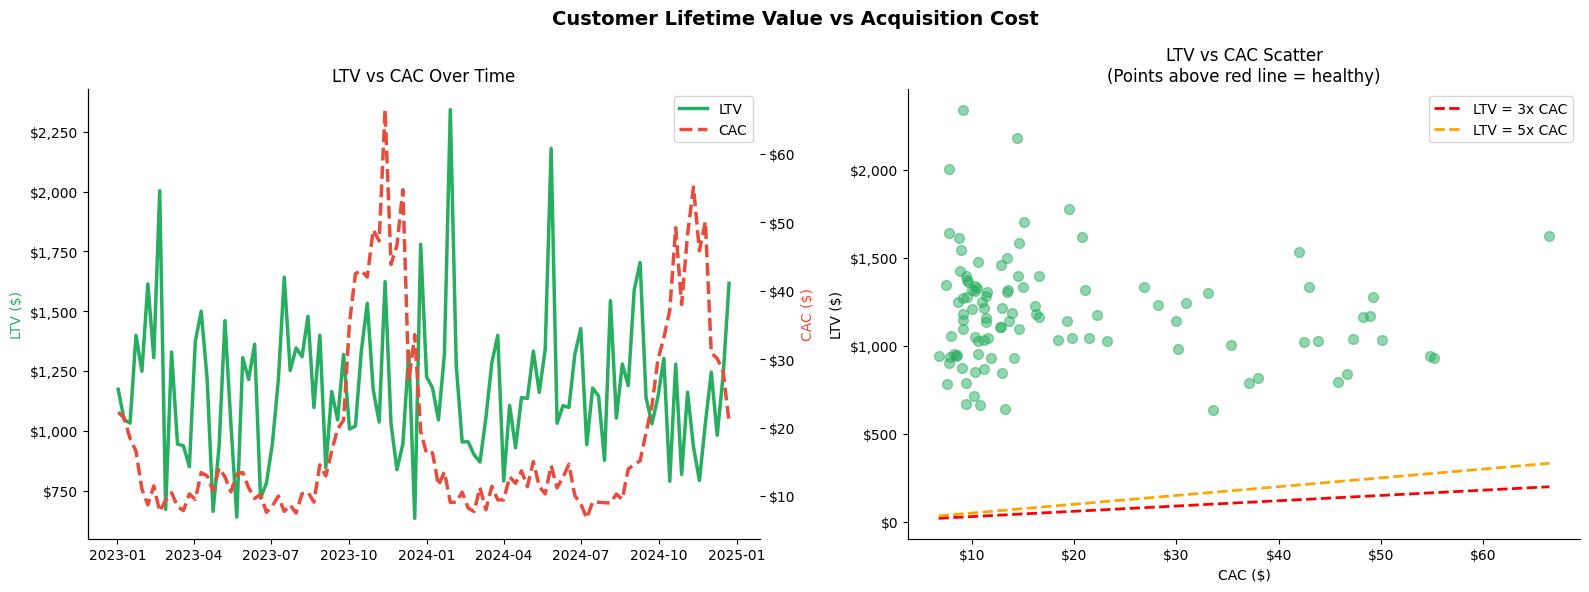

✅ LTV vs CAC saved!


In [4]:
 fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer Lifetime Value vs Acquisition Cost',
             fontsize=14, fontweight='bold')

# LTV and CAC over time
ax1 = axes[0]
ax2 = ax1.twinx()

ax1.plot(retention['date'], retention['ltv'],
         color='#27AE60', linewidth=2.5, label='LTV')
ax2.plot(conversion['date'], conversion['cac'],
         color='#E74C3C', linewidth=2.5,
         linestyle='--', label='CAC')

ax1.set_ylabel('LTV ($)', color='#27AE60')
ax2.set_ylabel('CAC ($)', color='#E74C3C')
ax1.set_title('LTV vs CAC Over Time')
ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:.0f}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

# LTV vs CAC scatter
axes[1].scatter(conversion['cac'], retention['ltv'],
                color=COLORS['conversion'], alpha=0.5, s=50)

# Add 3x line
x_range = np.linspace(conversion['cac'].min(),
                       conversion['cac'].max(), 100)
axes[1].plot(x_range, x_range * 3,
             color='red', linestyle='--',
             linewidth=2, label='LTV = 3x CAC')
axes[1].plot(x_range, x_range * 5,
             color='orange', linestyle='--',
             linewidth=2, label='LTV = 5x CAC')

axes[1].set_title('LTV vs CAC Scatter\n(Points above red line = healthy)')
axes[1].set_xlabel('CAC ($)')
axes[1].set_ylabel('LTV ($)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:.0f}'))
axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('12_ltv_vs_cac.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ LTV vs CAC saved!")

#  Payback Period Analysis:

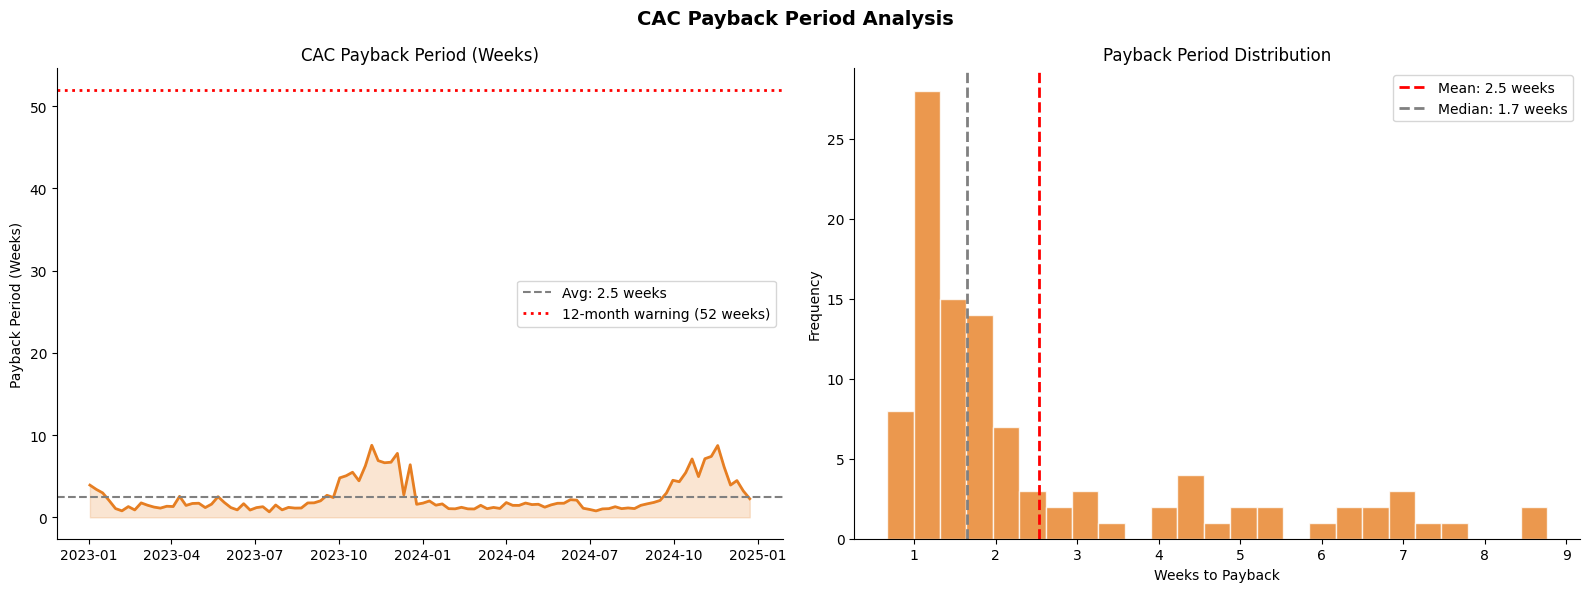

✅ Payback period saved!
Avg payback period: 2.5 weeks
Median payback:     1.7 weeks


In [6]:
# Payback period = CAC / (ARPU * Gross Margin)
# Assuming 70% gross margin for SaaS
gross_margin  = 0.70
payback_weeks = conversion['cac'] / \
                (conversion['arpu'] * gross_margin / 4)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CAC Payback Period Analysis',
             fontsize=14, fontweight='bold')

# Payback period over time
axes[0].plot(conversion['date'], payback_weeks,
             color=COLORS['highlight'], linewidth=2)
axes[0].fill_between(conversion['date'], payback_weeks,
                     alpha=0.2, color=COLORS['highlight'])
axes[0].axhline(payback_weeks.mean(), color='gray',
                linestyle='--',
                label=f'Avg: {payback_weeks.mean():.1f} weeks')
axes[0].axhline(52, color='red', linestyle=':',
                linewidth=2,
                label='12-month warning (52 weeks)')
axes[0].set_title('CAC Payback Period (Weeks)')
axes[0].set_ylabel('Payback Period (Weeks)')
axes[0].legend()

# Distribution
axes[1].hist(payback_weeks, bins=25,
             color=COLORS['highlight'],
             edgecolor='white', alpha=0.8)
axes[1].axvline(payback_weeks.mean(),
                color='red', linewidth=2,
                linestyle='--',
                label=f'Mean: {payback_weeks.mean():.1f} weeks')
axes[1].axvline(payback_weeks.median(),
                color='gray', linewidth=2,
                linestyle='--',
                label=f'Median: {payback_weeks.median():.1f} weeks')
axes[1].set_title('Payback Period Distribution')
axes[1].set_xlabel('Weeks to Payback')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('13_payback_period.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Payback period saved!")
print(f"Avg payback period: {payback_weeks.mean():.1f} weeks")
print(f"Median payback:     {payback_weeks.median():.1f} weeks")

#  Churn Impact on LTV:

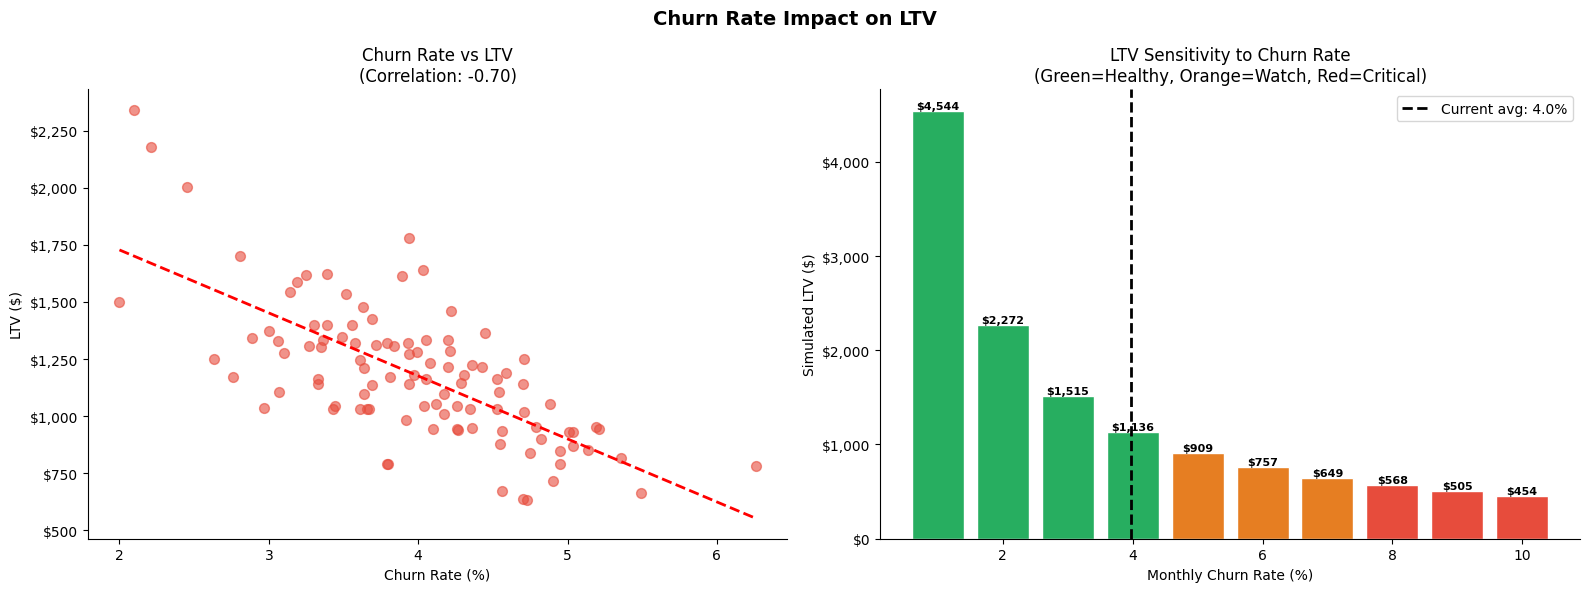

✅ Churn impact analysis saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Churn Rate Impact on LTV',
             fontsize=14, fontweight='bold')

# Churn vs LTV scatter
axes[0].scatter(retention['churn_rate_pct'],
                retention['ltv'],
                color=COLORS['retention'], alpha=0.6, s=50)
z = np.polyfit(retention['churn_rate_pct'],
               retention['ltv'], 1)
p = np.poly1d(z)
x_range = np.linspace(retention['churn_rate_pct'].min(),
                       retention['churn_rate_pct'].max(), 100)
axes[0].plot(x_range, p(x_range),
             color='red', linestyle='--', linewidth=2)
corr = retention['churn_rate_pct'].corr(retention['ltv'])
axes[0].set_title(f'Churn Rate vs LTV\n(Correlation: {corr:.2f})')
axes[0].set_xlabel('Churn Rate (%)')
axes[0].set_ylabel('LTV ($)')
axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Simulated LTV at different churn rates
churn_scenarios = np.arange(1, 11)
avg_arpu = conversion['arpu'].mean()
simulated_ltv = avg_arpu / (churn_scenarios / 100)

axes[1].bar(churn_scenarios, simulated_ltv,
            color=[COLORS['conversion'] if c <= 4
                   else COLORS['highlight'] if c <= 7
                   else COLORS['retention']
                   for c in churn_scenarios],
            edgecolor='white')
axes[1].axvline(retention['churn_rate_pct'].mean(),
                color='black', linewidth=2,
                linestyle='--',
                label=f"Current avg: {retention['churn_rate_pct'].mean():.1f}%")

for i, (c, ltv) in enumerate(zip(churn_scenarios, simulated_ltv)):
    axes[1].text(i + 1, ltv + 20,
                 f'${ltv:,.0f}', ha='center',
                 fontsize=8, fontweight='bold')

axes[1].set_title('LTV Sensitivity to Churn Rate\n(Green=Healthy, Orange=Watch, Red=Critical)')
axes[1].set_xlabel('Monthly Churn Rate (%)')
axes[1].set_ylabel('Simulated LTV ($)')
axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend()

plt.tight_layout()
plt.savefig('14_churn_ltv_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Churn impact analysis saved!")

# SaaS Health Dashboard:

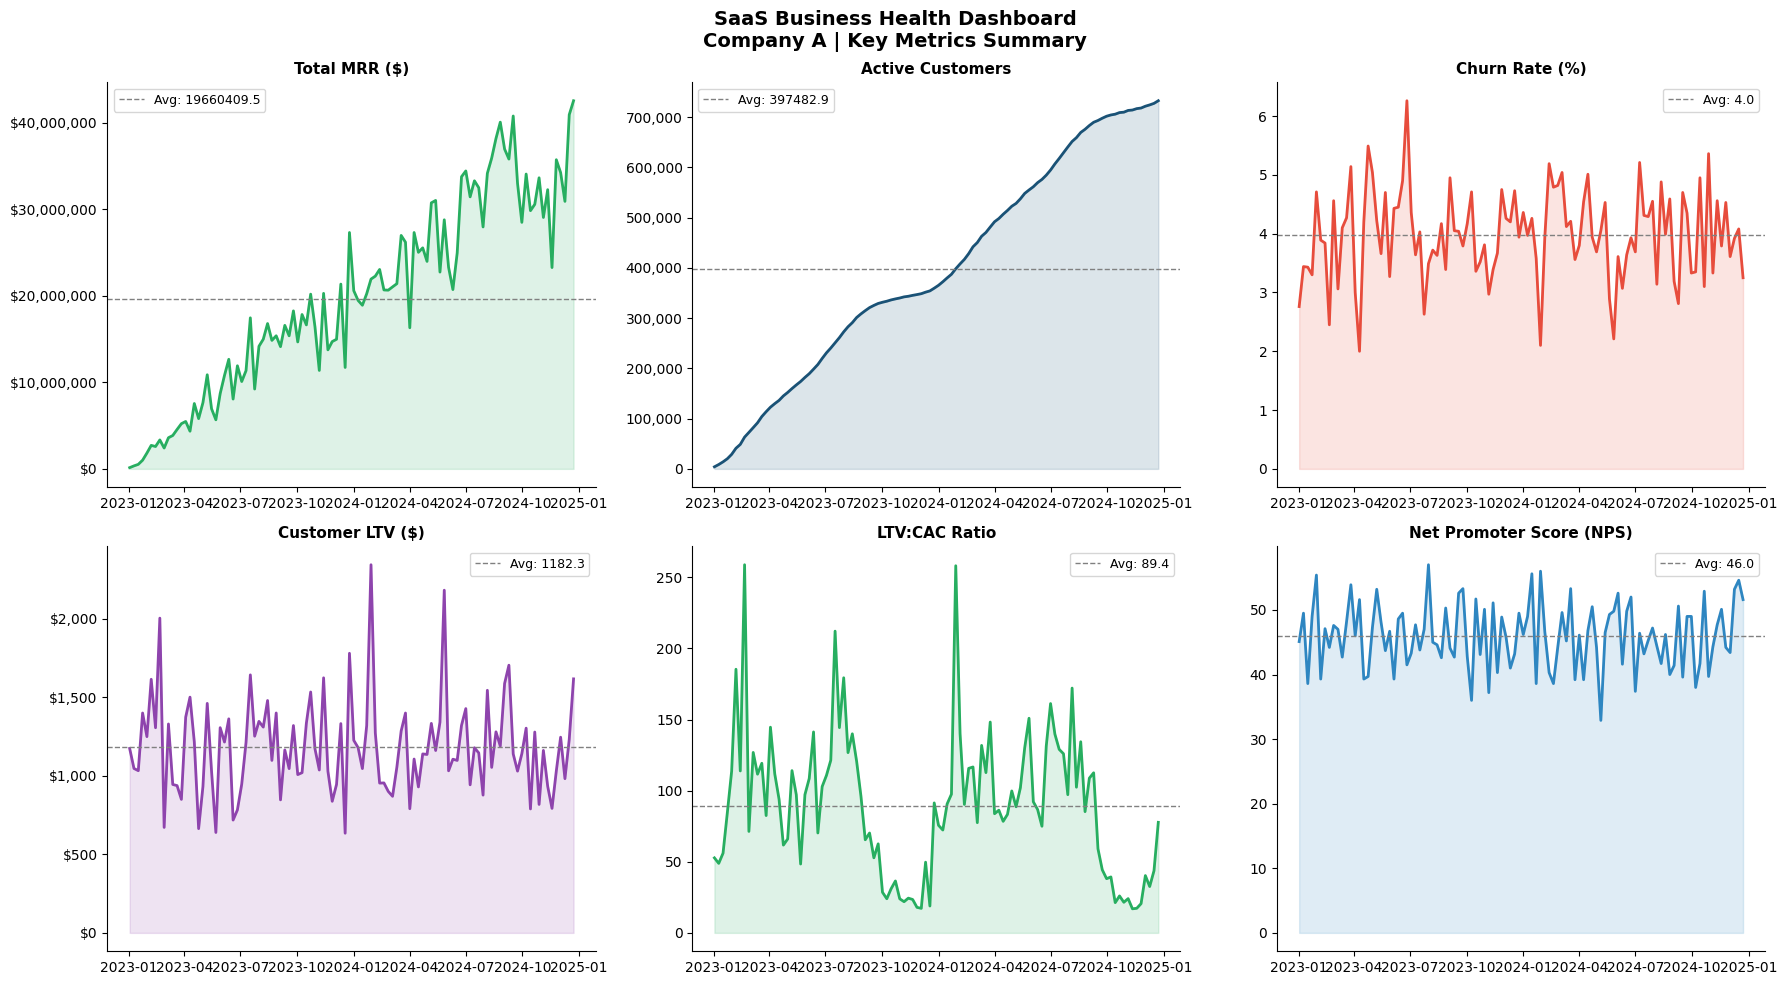

✅ SaaS health dashboard saved!


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SaaS Business Health Dashboard\nCompany A | Key Metrics Summary',
             fontsize=14, fontweight='bold')

metrics = [
    ('total_mrr',      'Total MRR ($)',           COLORS['conversion'],
     retention, FuncFormatter(lambda x, _: f'${x:,.0f}')),
    ('active_customers','Active Customers',        COLORS['awareness'],
     retention, FuncFormatter(lambda x, _: f'{x:,.0f}')),
    ('churn_rate_pct', 'Churn Rate (%)',           COLORS['retention'],
     retention, None),
    ('ltv',            'Customer LTV ($)',          '#8E44AD',
     retention, FuncFormatter(lambda x, _: f'${x:,.0f}')),
    ('ltv_cac_ratio',  'LTV:CAC Ratio',            COLORS['conversion'],
     retention, None),
    ('nps',            'Net Promoter Score (NPS)', '#2E86C1',
     retention, None)
]

for ax, (col, title, color, df, formatter) in \
        zip(axes.flatten(), metrics):
    ax.plot(df['date'], df[col], color=color, linewidth=2)
    ax.fill_between(df['date'], df[col], alpha=0.15, color=color)
    ax.set_title(title, fontweight='bold', fontsize=11)
    if formatter:
        ax.yaxis.set_major_formatter(formatter)
    ax.axhline(df[col].mean(), color='gray',
               linestyle='--', linewidth=1,
               label=f"Avg: {df[col].mean():.1f}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('15_saas_health_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SaaS health dashboard saved!")

# Key Metrics Summary:

In [9]:
print("=" * 55)
print("LTV/CAC ANALYSIS SUMMARY — COMPANY A SAAS")
print("=" * 55)
print(f"""
UNIT ECONOMICS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Avg CAC:              ${conversion['cac'].mean():,.0f}
  Avg LTV:              ${retention['ltv'].mean():,.0f}
  Avg LTV:CAC Ratio:    {retention['ltv_cac_ratio'].mean():.1f}x
  Avg Payback Period:   {payback_weeks.mean():.1f} weeks
  Avg Churn Rate:       {retention['churn_rate_pct'].mean():.2f}%
  Avg NPS:              {retention['nps'].mean():.0f}

BUSINESS HEALTH:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LTV:CAC > 3x:         ✅ {'YES' if retention['ltv_cac_ratio'].mean() > 3 else '❌ NO'}
  Churn < 5%:           ✅ {'YES' if retention['churn_rate_pct'].mean() < 5 else '❌ NO'}
  NPS > 40:             ✅ {'YES' if retention['nps'].mean() > 40 else '❌ NO'}
  Payback < 52 weeks:   ✅ {'YES' if payback_weeks.mean() < 52 else '❌ NO'}

RECOMMENDATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  The business is in HEALTHY unit economic territory.
  LTV:CAC of {retention['ltv_cac_ratio'].mean():.1f}x significantly exceeds
  the 3x minimum threshold for sustainable SaaS growth.
  Priority: Reduce churn from {retention['churn_rate_pct'].mean():.1f}%
  to below 3% to further improve LTV and margin.
""")

LTV/CAC ANALYSIS SUMMARY — COMPANY A SAAS

UNIT ECONOMICS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Avg CAC:              $19
  Avg LTV:              $1,182
  Avg LTV:CAC Ratio:    89.4x
  Avg Payback Period:   2.5 weeks
  Avg Churn Rate:       3.98%
  Avg NPS:              46

BUSINESS HEALTH:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LTV:CAC > 3x:         ✅ YES
  Churn < 5%:           ✅ YES
  NPS > 40:             ✅ YES
  Payback < 52 weeks:   ✅ YES

RECOMMENDATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  The business is in HEALTHY unit economic territory.
  LTV:CAC of 89.4x significantly exceeds
  the 3x minimum threshold for sustainable SaaS growth.
  Priority: Reduce churn from 4.0%
  to below 3% to further improve LTV and margin.



In [10]:
from google.colab import files
charts = ['11_ltv_cac_ratio.png', '12_ltv_vs_cac.png',
          '13_payback_period.png', '14_churn_ltv_impact.png',
          '15_saas_health_dashboard.png']
for chart in charts:
    files.download(chart)
print("✅ All Notebook 3 charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All Notebook 3 charts downloaded!
